# Causal Inference
# School of Information, University of Michigan 
## Week 2

### Resources:
- Course Manual, which can be found in Coursera
- ["Nike Says Its \$250 Running Shoes Will Make You Run Much Faster. What if That's Actually True?"](NYT_Nike.pdf)

## Part 1

### Background
Nike claims that its $250 running shoes called “Vaporfly” will make you run much faster!

### Data 

The data file “lecture2_match_reg.csv” contains 5 variables for 24,699 runners that qualified for and ran the same marathon. Below are the descriptions of each variable in the data: 

- \`age\`: age of runner (min value: 18, max value: 55)
- \`male\`: dummy variable for gender; equal to 0 if female, 1 if male 
- \`marathoner_type\`: 
    - “seasoned” if runner has at least 3 prior completed marathons, 
    - “enthusiastic” if runner has completed 1 or 2 prior completed marathons, 
    - “first_timer” if this is a runner’s first time running a marathon 
- \`vaporfly\`: 1 if a runner’s racing shoe is Nike Vaporfly, 0 otherwise 
- \`race_time\`: marathon completion time in seconds

In [1]:
#Import Statements. Run this cell.
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from causalinference import CausalModel
from mads.lib.path import assets

In [2]:
#Uploading data for assignment. Run this cell.
file = assets.find("lecture2_match_reg.csv")
data_marathon = pd.read_csv(file)

#Uncomment below to see the first five lines of the dataframe.
data_marathon.head()

,age,marathoner_type,vaporfly,race_time,male
0,41,enthusiastic,1,11755.176,1
1,42,enthusiastic,1,14980.950,0
2,39,enthusiastic,0,12342.542,1
3,29,enthusiastic,0,13142.107,1
4,34,enthusiastic,1,13255.874,0


## Questions

Using data on race times, we want to explore the accuracy of this claim using marathon runners data. To be more specific, Nike’s claim is that runners run 4% faster with Vaporfly shoes.

**Note**: You can refer to the manual for the methods we use in the assignment if you need to. 

**Use the data_marathon dataframe uploaded above to answer the questions below unless otherwise specified.**

**1.** In order to be able to interpret our results in the same format (i.e. percentage change), we want to conduct our analysis over the (natural) log of race times. Transform the original race_time variable by taking its natural log, call the new variable `ln_race_time`, and add it to the data_marathon dataframe. We will use *ln_race_time* as our outcome variable throughout the entire assignment. (1 pt)

**Tip**: Use the `.head()` or `.sample()` methods to check your work.

In [ ]:
# create the log outcome so model coefficients can be interpreted approximately as percentage changes
data_marathon["ln_race_time"] = np.log(data_marathon["race_time"])

# check that the new column was added correctly
data_marathon[["race_time", "ln_race_time"]].head()


In [ ]:
# Hidden Tests, checking the value of ln_race_time.

**2.** Compute the means of ln_race_time for runners who wore Vaporfly and for those who did not. What is the difference between the means across those two groups? Assign the value to the variable `mean_diff1_2`. Ensure that the response is correct to at least 4 decimal points and that its data type is float. (1 pt)

In [ ]:
# compute average log race time separately for treated and untreated runners
mean_vaporfly = data_marathon.loc[data_marathon["vaporfly"] == 1, "ln_race_time"].mean()
mean_no_vaporfly = data_marathon.loc[data_marathon["vaporfly"] == 0, "ln_race_time"].mean()

# treated minus untreated: negative values mean Vaporfly runners had lower, faster log race times
mean_diff1_2 = float(mean_vaporfly - mean_no_vaporfly)
mean_diff1_2


In [ ]:
# Hidden Tests, checking the value of mean_diff1_2.

**3.** Suppose the only thing that matters for race time, besides potentially shoes, is age. We want to estimate average treatment effects (ATE) of wearing Nike Vaporfly shoes, using nearest neighbor matching on variable *age* with respect to Euclidean distance. Use the `CausalModel` module and assign the ATE to the variable `ate1_3`. Ensure that the data type of *ate1_3* is float. (Round to four decimal places.) (2 pts)

**Use the data_sample1_3 dataframe for your response below (Question 3); data_sample1_3 is a subsample of our marathon data, which will save computational time for this question.**

In [ ]:
data_sample1_3 = data_marathon.sample(n = 2000, random_state = 123)

In [ ]:
# estimate ATE by nearest-neighbor matching using only age as the matching covariate
cm1_3 = CausalModel(
    Y=data_sample1_3["ln_race_time"].values,
    D=data_sample1_3["vaporfly"].values,
    X=data_sample1_3[["age"]].values
)

# use a weight of 1 so distance is simple Euclidean distance on age
cm1_3.est_via_matching(weights=np.array([1.0]), matches=1)

# store the estimated average treatment effect as a rounded float
ate1_3 = float(round(cm1_3.estimates["matching"]["ate"], 4))
ate1_3


In [ ]:
# Hidden Tests, checking the value of ate1_3.

**4.** We want to conduct propensity score matching to estimate the ATE of running with Nike Vaporfly shoes.

**Note: We are back to using the original dataframe data_marathon.**

**4a.** Create binary variables called `seasoned` and `enthusiastic` that are equal to 1 for the corresponding *marathoner_type* values and 0 otherwise. Add these variables to the data_marathon dataframe. (1 pt)

**Tip**: Use the `np.where()` method to create the binary variables.

In [ ]:
# create dummy variables for the observed experience categories
data_marathon["seasoned"] = np.where(data_marathon["marathoner_type"] == "seasoned", 1, 0)
data_marathon["enthusiastic"] = np.where(data_marathon["marathoner_type"] == "enthusiastic", 1, 0)

# first-timers are the omitted/reference group when both dummies equal 0
data_marathon[["marathoner_type", "seasoned", "enthusiastic"]].head()


In [ ]:
# Hidden Tests, checking the values of seasoned and enthusiastic.

**4b.** Use propensity score matching   with a logit model to estimate the ATE of wearing Nike Vaporfly shoes. Use the variables *age*, *male*, *seasoned*, *enthusiastic* and the method `est_via_weighting()` from the CausalModel module. Assign the ATE to the variable `ate1_4b` and ensure that its data type is float. (**Round** to **three** decimal places.) (2 pts)

**Use the data_sample1_4b dataframe for your response below (Question 3); data_sample1_3 is a subsample of our marathon data, which will save computational time for this question.**

In [ ]:
data_sample1_4b = data_marathon.sample(n = 2000, random_state = 123)

In [ ]:
# estimate propensity scores from observed covariates, then use weighting for the ATE
cm1_4b = CausalModel(
    Y=data_sample1_4b["ln_race_time"].values,
    D=data_sample1_4b["vaporfly"].values,
    X=data_sample1_4b[["age", "male", "seasoned", "enthusiastic"]].values
)

# est_propensity uses a logistic regression of treatment on the supplied covariates
cm1_4b.est_propensity()
cm1_4b.est_via_weighting()

# store the weighted ATE as a rounded float
ate1_4b = float(round(cm1_4b.estimates["weighting"]["ate"], 3))
ate1_4b


In [ ]:
#Hidden Tests, checking the value of ate1_4b.

## Part 2

> “Although regression is a many-splendored thing, we think of it as an automated matchmaker. Specifically, regression estimates are weighted averages of multiple matched comparisons of the sort constructed for the groups in our stylized matching matrix.” (Mastering Metrics, p. 49)

We now want to use controlled regression to conduct our analysis. 

----

Note that Question 1 asks you to estimate a mis-specified regression model; Question 2 requires you to describe the OVB in words using the information provided; Question 3 asks you to calculate the OVB (which normally is not possible).

**1.** Using robust standard errors, regress *ln_race_time* on variables *vaporfly*, *male*, *seasoned*, and *enthusiastic*. Assign the results (using the `.get_robustcov_results()` method) to the variable `ols_robust2_1`.  (2 pts)

In [ ]:
# regress log race time on treatment and observed controls, excluding age on purpose
ols_model2_1 = smf.ols(
    "ln_race_time ~ vaporfly + male + seasoned + enthusiastic",
    data=data_marathon
).fit()

# use robust standard errors because the error variance may differ across runners
ols_robust2_1 = ols_model2_1.get_robustcov_results(cov_type="HC1")
ols_robust2_1.summary()


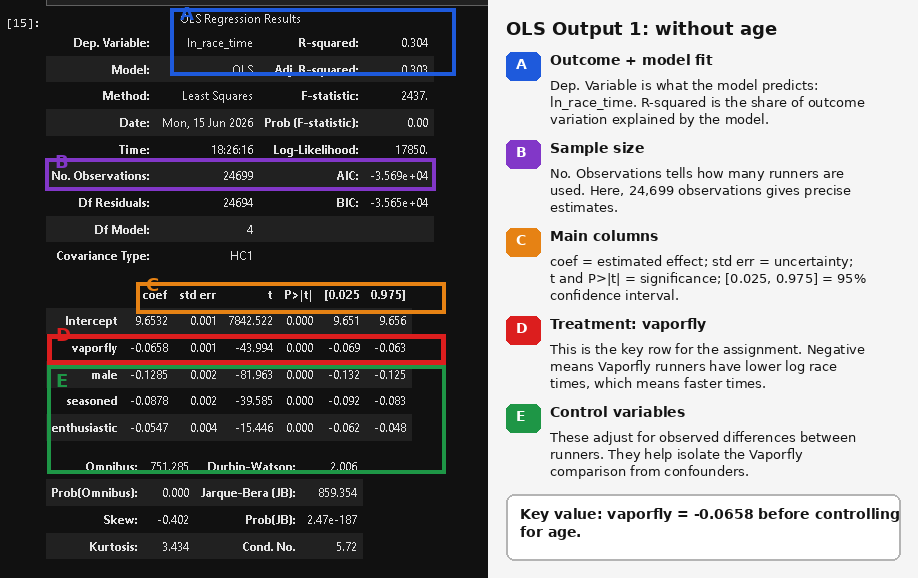

In [ ]:
# Hidden Tests, checking the coefficients and standard errors of ols_model2_1.

**2.** Vaporfly shoes are pretty expensive, with a retail price of $250. Younger runners, who we expect would have lower income levels, may find it too expensive to purchase. Furthermore, it has been documented that in endurance type races, such as marathons, older runners are actually faster than their younger peers. Answer the following questions based on this information. 

**2a.** Based on the information above, would you expect the effect of the omitted variable *age* on the outcome variable *ln_race_time* to be positive or negative? (1 pt)

**Note**: This question will be manually graded.

---

### STUDENT ANSWER:

I would expect the effect of **age** on `ln_race_time` to be **negative**.

Reasoning:

$
\text{age} \uparrow \quad \Rightarrow \quad \ln(\text{race time}) \downarrow
$

Based on the assignment context, older runners are expected to be more experienced or stronger marathon performers, so higher age is associated with **lower race times**. Since lower race time means faster performance, age should have a **negative coefficient** in a model predicting `ln_race_time`.

A good free-response answer:

> I would expect age to have a negative effect on `ln_race_time`. If older runners tend to be more experienced or faster, then as age increases, race time should decrease. Because the outcome is log race time, a negative age coefficient would mean that older age is associated with a lower predicted race time, holding other factors constant.



**2b.** If we were to regress the omitted variable *age* on the treatment variable *vaporfly*, would you expect the coefficient in front of the variable *vaporfly* to be positive or negative? (1 pt)

**Note**: This question will be manually graded.

---

### STUDENT ANSWER:

I would expect the coefficient in front of `vaporfly` to be **positive**.

That regression would look like:

$
age_i = \alpha + \gamma \cdot vaporfly_i + u_i
$

Here, (\gamma) tells us whether Vaporfly users are older or younger than non-Vaporfly users on average.

Based on the assignment context, Vaporfly shoes are expensive, so runners who wear them may be older on average because older runners may have more income or resources to buy them. Therefore:

$
vaporfly = 1 \quad \Rightarrow \quad age \uparrow
$

So the expected coefficient on `vaporfly` is **positive**.

A good free-response answer:

> I would expect the coefficient on `vaporfly` to be positive when regressing age on Vaporfly use. This would mean that runners who wear Vaporfly shoes are older on average than runners who do not wear Vaporfly shoes. This makes sense because Vaporfly shoes are expensive, and older runners may be more likely to have the financial resources or running commitment needed to purchase them.



**2c.** State the OVB (omitted variable bias) formula. Based on it, would you expect the omitted variable bias to be positive or negative? Explain. (2 pts) 

**Note**: This question will be manually graded.

The omitted variable bias formula is:

$
\text{Bias} = \beta_{age} \times \delta
$

where:

$
\beta_{age}
$

is the effect of the omitted variable `age` on the outcome `ln_race_time`, and

$
\delta
$

is the coefficient from regressing the omitted variable `age` on the treatment variable `vaporfly`.

In this case:

$
\beta_{age} < 0
$

because older runners are expected to have lower `ln_race_time`, meaning faster race times.

And:

$
\delta > 0
$

because Vaporfly users are expected to be older on average than non-Vaporfly users.

Therefore:

$
\text{Bias} = (-) \times (+) = (-)
$

So I would expect the omitted variable bias to be **negative**.

A good free-response answer:

> The omitted variable bias formula is the effect of the omitted variable on the outcome multiplied by the relationship between the omitted variable and the treatment variable. Here, age is expected to have a negative effect on `ln_race_time` because older runners are expected to have lower race times. Vaporfly use is expected to be positively associated with age because Vaporfly users may be older on average. Therefore, the omitted variable bias is negative. This means that omitting age likely makes the estimated Vaporfly coefficient too negative, overstating the apparent benefit of Vaporfly shoes.



**3.** Let’s confirm the omitted variable bias. Run the regression from Part 2, Question 1 but this time also control for runners’ age by including the additional control variable age. 

In [ ]:
# include age to check whether the omitted-variable-bias prediction is supported empirically
ols_model2_3 = smf.ols(
    "ln_race_time ~ vaporfly + male + seasoned + enthusiastic + age",
    data=data_marathon
).fit()

# use the same robust standard error approach as in the earlier regression
ols_robust2_3 = ols_model2_3.get_robustcov_results(cov_type="HC1")
ols_robust2_3.summary()


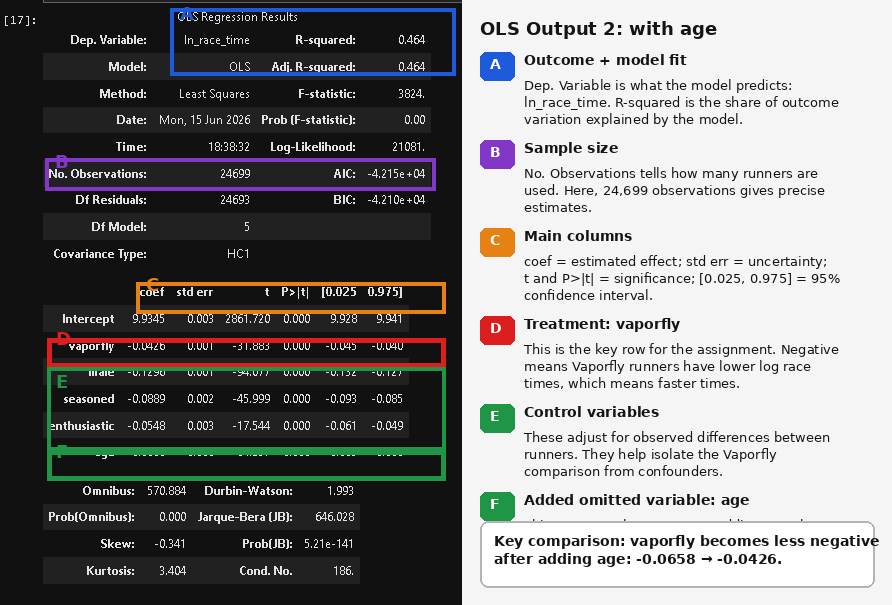

### How to read the OLS table

The **most important row for this assignment is `vaporfly`**, because that is the treatment variable. Its coefficient tells you the estimated relationship between wearing Vaporfly shoes and `ln_race_time`.

In the first model:

$
\hat{\beta}_{vaporfly} = -0.0658
$

In the second model, after adding age:

$
\hat{\beta}_{vaporfly} = -0.0426
$

Because the outcome is log race time, these are approximately percentage changes. Negative means **lower race time**, which means **faster performance**.

### Variables to focus on

| Part             | What to focus on                | Why it matters                                                                                                                 |                          |                                                                                |
| ---------------- | ------------------------------- | ------------------------------------------------------------------------------------------------------------------------------ | ------------------------ | ------------------------------------------------------------------------------ |
| `Dep. Variable`  | `ln_race_time`                  | This tells you the outcome being predicted. Since it is logged, coefficients are interpreted approximately as percent changes. |                          |                                                                                |
| `coef` column    | Especially `vaporfly` and `age` | This is the estimated effect/direction of each variable.                                                                       |                          |                                                                                |
| `vaporfly` row   | Treatment variable              | This is the main variable for the causal question.                                                                             |                          |                                                                                |
| `age` row        | Omitted variable                | This is the confounder used in the omitted variable bias question.                                                             |                          |                                                                                |
| Coefficient table headers              | `coef`, `std err`, `t`, `P> |t|`, `[0.025 0.975]`   | These columns tell you how to interpret each variable’s row. The coef column gives the estimated effect. The `P>|t|` column tells whether the estimate is statistically significant. The `[0.025, 0.975]` columns give the 95% confidence interval, which tells the likely range of the true coefficient.    | Statistical significance | Very small p-values suggest the coefficient is statistically different from 0. |
| `[0.025, 0.975]` | 95% confidence interval         | If the interval does not include 0, the estimate is statistically significant.                                                 |                          |                                                                                |
| `R-squared`      | Model fit                       | Shows how much variation in `ln_race_time` the model explains. It improves from 0.304 to 0.464 after adding age.               |                          |                                                                                |

### Key interpretation

The Vaporfly coefficient becomes **less negative** after adding age:

$
-0.0658 \rightarrow -0.0426
$

That means the model without age was making the Vaporfly effect look **too large**. This supports the omitted variable bias explanation: age was a confounder, and omitting it biased the Vaporfly coefficient downward.


Compare the two coefficients in front of the treatment variable vaporfly, what do you observe? Based on your observation, are the results consistent with your previous intuitive analysis of OVB? (2 pts) 

**Note**: This question will be manually graded.

---

### STUDENT ANSWER:

The coefficient on `vaporfly` **decreases in magnitude** after adding `age`.

From the first regression without age:

$
\hat{\beta}_{vaporfly} = -0.0658
$

From the regression with age included:

$
\hat{\beta}_{vaporfly} = -0.0426
$

So the Vaporfly coefficient moves from about **-6.6%** to about **-4.3%**.

That means the estimated Vaporfly advantage becomes **smaller** after controlling for age. In the model without age, Vaporfly runners appeared to have race times about 6.4% to 6.6% lower. After adding age, the estimated advantage is closer to 4.2% to 4.3% lower.

This is consistent with the previous omitted variable bias analysis. We expected the omitted variable bias from excluding age to be **negative** because:

$
\text{OVB} = \beta_{age} \times \delta
$

Age has a negative relationship with `ln_race_time`:

$
\beta_{age} < 0
$

and Vaporfly use is positively related to age:

$
\delta > 0
$

so:

$
(-) \times (+) = (-)
$

A negative omitted variable bias means the model without age should make the Vaporfly coefficient **too negative**. That is exactly what we observe: once age is included, the Vaporfly coefficient becomes less negative, moving from `-0.0658` to `-0.0426`.

You can write:

> The coefficient on `vaporfly` changes from approximately -0.0658 in the model without age to approximately -0.0426 in the model with age. Therefore, after controlling for age, the estimated Vaporfly effect becomes less negative. This is consistent with the omitted variable bias analysis. We expected age to have a negative effect on `ln_race_time`, and we expected Vaporfly use to be positively associated with age. Therefore, the omitted variable bias should be negative. Since the model that omits age produced a coefficient that was too negative, and the coefficient moved closer to zero after age was included, the observed results match the predicted direction of OVB.

